# E10 — Rectangular Matrices

## Overview

This experiment tests whether **Muon works on non-square (rectangular) matrices**. The standard matrix sensing formulation uses square d × d matrices, but real-world problems often involve rectangular matrices (e.g., m × n where m ≠ n). Muon's spectral normalization via SVD is well-defined for rectangular matrices, but its practical effectiveness may depend on the aspect ratio.

The key question: *Does matrix shape asymmetry (m ≠ n) affect Muon and SGD differently? Is Muon's advantage preserved on tall (m > n) and wide (m < n) matrices?*

### Key Metrics
- **K_epsilon**: Iterations to reach ε = 0.01 precision
- **time_s**: Wall-clock time (accounts for per-iteration cost differences)
- **min_loss**: Best loss achieved during optimization
- **I_conv**: Convergence flag


## Scientific Question & Hypothesis

**Primary Hypothesis (H₁):** Muon maintains its convergence advantage on rectangular matrices, regardless of aspect ratio (tall vs. wide). SVD is well-defined for any matrix shape, so spectral normalization should work uniformly.

**Null Hypothesis (H₀):** Matrix shape asymmetry differentially affects Muon and SGD, causing one algorithm to lose its advantage on non-square matrices.

**Rationale:** For an m × n matrix, SVD produces U (m × m), Σ (m × n), and V (n × n). The spectral normalization D = UVᵀ has shape m × n, same as the parameter matrix. The theoretical properties of spectral normalization (unit spectral norm, alignment with gradient) hold for rectangular matrices just as for square ones.

However, practical considerations differ:
- **Tall matrices (m > n):** The problem may be better conditioned due to more row constraints.
- **Wide matrices (m < n):** The problem may be underdetermined, making recovery harder.

**Experimental Parameters:**
| Parameter | Value |
|-----------|-------|
| Matrix shapes (m, n) | {(50,100), (100,50), (100,200), (200,100)} |
| Target rank r | min(m,n) / 10 |
| Measurements | 2 · min(m,n) · r |
| Learning rate η | 0.01 |
| Seeds | 8 |
| Max iterations | 2000 |
| ε threshold | 0.01 |


## Experimental Design

**Problem:** Matrix Sensing on rectangular matrices.

**Matrix shapes tested:**
| Shape (m × n) | Type | min(m,n) | r = min/10 | m_meas |
|---------------|------|----------|------------|--------|
| 50 × 100 | Wide (m < n) | 50 | 5 | 500 |
| 100 × 50 | Tall (m > n) | 50 | 5 | 500 |
| 100 × 200 | Wide (m < n) | 100 | 10 | 2000 |
| 200 × 100 | Tall (m > n) | 100 | 10 | 2000 |

**Key design feature:** We pair shapes with the same min(m,n) to isolate the effect of aspect ratio:
- Pair 1: (50,100) vs (100,50) — same min = 50
- Pair 2: (100,200) vs (200,100) — same min = 100

**Algorithms compared:**
- **Muon-Exact**: Full SVD-based spectral normalization
- **SGD**: Standard gradient descent with momentum (μ = 0.9)

**Total runs:** 2 algorithms × 4 shapes × 8 seeds = 64 experiments.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

df = pd.read_csv('../results_v3/E10_detailed_results.csv')

print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"Algorithms: {df['algo'].unique()}")
print(f"m values: {sorted(df['m'].unique())}")
print(f"n values: {sorted(df['n'].unique())}")
print(f"Seeds: {sorted(df['seed'].unique())}")

# Create shape label
df['shape'] = df['m'].astype(str) + 'x' + df['n'].astype(str)
print(f"Shapes: {df['shape'].unique()}")


Total rows: 64
Columns: ['algo', 'd', 'r', 'lr', 'noise', 'dist', 'init_scale', 'seed', 'iters', 'm', 'n', 'final_loss', 'min_loss', 'K_epsilon', 'time_s', 'I_conv', 'F_eps']
Algorithms: ['Muon-Exact' 'SGD']
m values: [np.int64(50), np.int64(100), np.int64(200)]
n values: [np.int64(50), np.int64(100), np.int64(200)]
Seeds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Shapes: ['50x100' '100x50' '100x200' '200x100']


## Exploratory Data Analysis


In [10]:
# Summary statistics
summary = df.groupby(['algo', 'shape']).agg({
    'K_epsilon': ['count', 'mean', 'std', 'min', 'max'],
    'min_loss': ['mean', 'std'],
    'final_loss': ['mean', 'std'],
    'time_s': ['mean', 'std'],
    'I_conv': ['mean']
}).round(4)

print("=" * 80)
print("SUMMARY STATISTICS by (algo, shape)")
print("=" * 80)
print(summary)


SUMMARY STATISTICS by (algo, shape)
                   K_epsilon                         min_loss          \
                       count    mean     std min max     mean     std   
algo       shape                                                        
Muon-Exact 100x200         8  52.125  0.6409  51  53   0.0045  0.0003   
           100x50          8  40.375  0.9161  39  42   0.0024  0.0002   
           200x100         8  52.125  0.6409  51  53   0.0046  0.0005   
           50x100          8  40.000  0.7559  39  41   0.0023  0.0003   
SGD        100x200         8  56.000  0.0000  56  56   0.0000  0.0000   
           100x50          8  48.875  0.6409  48  50   0.0000  0.0000   
           200x100         8  55.875  0.6409  55  57   0.0000  0.0000   
           50x100          8  49.125  0.3536  49  50   0.0000  0.0000   

                   final_loss             time_s          I_conv  
                         mean     std       mean      std   mean  
algo       shape          

## Comparative Analysis: Muon vs SGD by Matrix Shape


In [11]:
MUON_COLOR = '#2E86AB'
SGD_COLOR = '#F18F01'

shapes = sorted(df['shape'].unique())
print("=" * 80)
print("PAIRED COMPARISON: Muon vs SGD by Matrix Shape")
print("=" * 80)

results = []
for shape in shapes:
    m_val = df[df['shape'] == shape]['m'].iloc[0]
    n_val = df[df['shape'] == shape]['n'].iloc[0]

    muon_data = df[(df['algo'] == 'Muon-Exact') & (df['shape'] == shape)].sort_values('seed')['K_epsilon'].values
    sgd_data = df[(df['algo'] == 'SGD') & (df['shape'] == shape)].sort_values('seed')['K_epsilon'].values

    diff = muon_data - sgd_data
    t_stat, p_val = stats.ttest_rel(muon_data, sgd_data)
    cohens_d = np.mean(diff) / np.std(diff, ddof=1) if np.std(diff, ddof=1) > 0 else 0
    rho_k = np.mean(sgd_data) / np.mean(muon_data) if np.mean(muon_data) > 0 else 0

    results.append({
        'shape': shape,
        'm': m_val,
        'n': n_val,
        'type': 'tall' if m_val > n_val else 'wide',
        'muon_mean_k': np.mean(muon_data),
        'sgd_mean_k': np.mean(sgd_data),
        'diff_mean': np.mean(diff),
        'rho_K': rho_k,
        't_stat': t_stat,
        'p_value': p_val,
        'cohens_d': cohens_d,
        'muon_time': df[(df['algo'] == 'Muon-Exact') & (df['shape'] == shape)]['time_s'].mean(),
        'sgd_time': df[(df['algo'] == 'SGD') & (df['shape'] == shape)]['time_s'].mean(),
        'muon_conv': df[(df['algo'] == 'Muon-Exact') & (df['shape'] == shape)]['I_conv'].mean(),
        'sgd_conv': df[(df['algo'] == 'SGD') & (df['shape'] == shape)]['I_conv'].mean()
    })

    print(f"Shape {shape} ({m_val}x{n_val}, {'tall' if m_val > n_val else 'wide'}):")
    print(f"  Muon:  K_ε = {np.mean(muon_data):.1f} ± {np.std(muon_data, ddof=1):.1f}")
    print(f"  SGD:   K_ε = {np.mean(sgd_data):.1f} ± {np.std(sgd_data, ddof=1):.1f}")
    print(f"  ρ_K = {rho_k:.2f}x, t = {t_stat:+.3f}, p = {p_val:.4f}")

results_df = pd.DataFrame(results)
print("" + "=" * 80)
print(results_df[['shape', 'type', 'muon_mean_k', 'sgd_mean_k', 'rho_K', 'p_value', 'cohens_d']].to_string(index=False))


PAIRED COMPARISON: Muon vs SGD by Matrix Shape
Shape 100x200 (100x200, wide):
  Muon:  K_ε = 52.1 ± 0.6
  SGD:   K_ε = 56.0 ± 0.0
  ρ_K = 1.07x, t = -17.102, p = 0.0000
Shape 100x50 (100x50, tall):
  Muon:  K_ε = 40.4 ± 0.9
  SGD:   K_ε = 48.9 ± 0.6
  ρ_K = 1.21x, t = -20.115, p = 0.0000
Shape 200x100 (200x100, tall):
  Muon:  K_ε = 52.1 ± 0.6
  SGD:   K_ε = 55.9 ± 0.6
  ρ_K = 1.07x, t = -11.966, p = 0.0000
Shape 50x100 (50x100, wide):
  Muon:  K_ε = 40.0 ± 0.8
  SGD:   K_ε = 49.1 ± 0.4
  ρ_K = 1.23x, t = -40.272, p = 0.0000
  shape type  muon_mean_k  sgd_mean_k    rho_K      p_value   cohens_d
100x200 wide       52.125      56.000 1.074341 5.734341e-07  -6.046469
 100x50 tall       40.375      48.875 1.210526 1.879336e-07  -7.111610
200x100 tall       52.125      55.875 1.071942 6.481040e-06  -4.230571
 50x100 wide       40.000      49.125 1.228125 1.516702e-09 -14.238458


## Visualizations

### Plot 1: K_ε by Matrix Shape

Comparison of convergence speed across different rectangular matrix shapes.


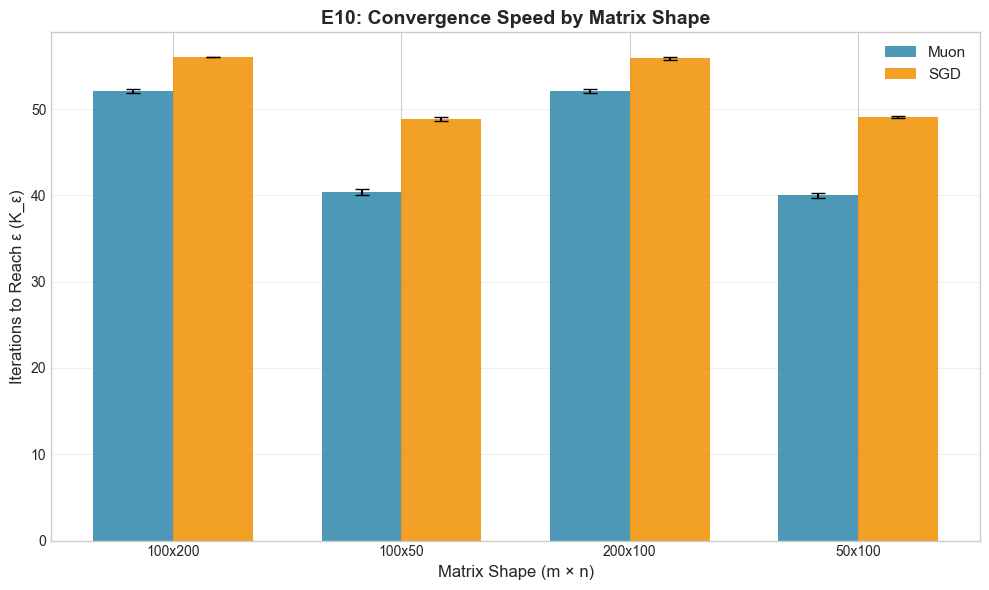

Saved: E10_K_epsilon_by_shape.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_data = df.groupby(['algo', 'shape'])['K_epsilon'].agg(['mean', 'std', 'count']).reset_index()
plot_data['se'] = plot_data['std'] / np.sqrt(plot_data['count'])

x_pos = np.arange(len(shapes))
width = 0.35

muon_vals = [plot_data[(plot_data['algo'] == 'Muon-Exact') & (plot_data['shape'] == s)]['mean'].values[0] for s in shapes]
muon_errs = [plot_data[(plot_data['algo'] == 'Muon-Exact') & (plot_data['shape'] == s)]['se'].values[0] for s in shapes]
sgd_vals = [plot_data[(plot_data['algo'] == 'SGD') & (plot_data['shape'] == s)]['mean'].values[0] for s in shapes]
sgd_errs = [plot_data[(plot_data['algo'] == 'SGD') & (plot_data['shape'] == s)]['se'].values[0] for s in shapes]

bars1 = ax.bar(x_pos - width/2, muon_vals, width, yerr=muon_errs, capsize=5,
               label='Muon', color=MUON_COLOR, alpha=0.85)
bars2 = ax.bar(x_pos + width/2, sgd_vals, width, yerr=sgd_errs, capsize=5,
               label='SGD', color=SGD_COLOR, alpha=0.85)

ax.set_xlabel('Matrix Shape (m × n)', fontsize=12)
ax.set_ylabel('Iterations to Reach ε (K_ε)', fontsize=12)
ax.set_title('E10: Convergence Speed by Matrix Shape', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(shapes)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../analysis_report/E10_K_epsilon_by_shape.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: E10_K_epsilon_by_shape.png")


### Plot 2: Wall-Clock Time by Matrix Shape

Time comparison reveals the practical cost including per-iteration overhead.


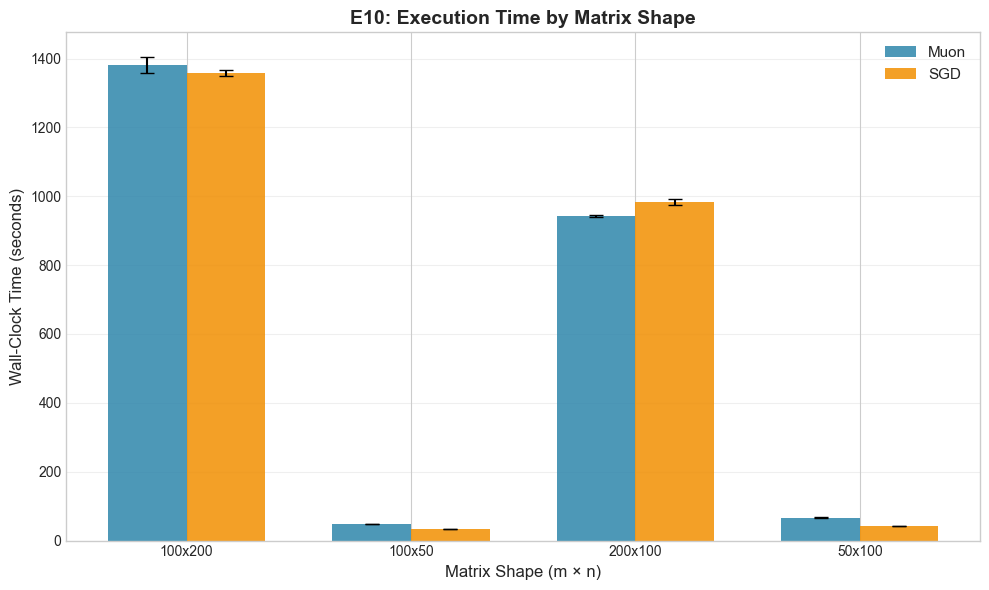

Saved: E10_time_by_shape.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

time_data = df.groupby(['algo', 'shape'])['time_s'].agg(['mean', 'std', 'count']).reset_index()
time_data['se'] = time_data['std'] / np.sqrt(time_data['count'])

muon_times = [time_data[(time_data['algo'] == 'Muon-Exact') & (time_data['shape'] == s)]['mean'].values[0] for s in shapes]
muon_terrs = [time_data[(time_data['algo'] == 'Muon-Exact') & (time_data['shape'] == s)]['se'].values[0] for s in shapes]
sgd_times = [time_data[(time_data['algo'] == 'SGD') & (time_data['shape'] == s)]['mean'].values[0] for s in shapes]
sgd_terrs = [time_data[(time_data['algo'] == 'SGD') & (time_data['shape'] == s)]['se'].values[0] for s in shapes]

x_pos = np.arange(len(shapes))
width = 0.35

bars1 = ax.bar(x_pos - width/2, muon_times, width, yerr=muon_terrs, capsize=5,
               label='Muon', color=MUON_COLOR, alpha=0.85)
bars2 = ax.bar(x_pos + width/2, sgd_times, width, yerr=sgd_terrs, capsize=5,
               label='SGD', color=SGD_COLOR, alpha=0.85)

ax.set_xlabel('Matrix Shape (m × n)', fontsize=12)
ax.set_ylabel('Wall-Clock Time (seconds)', fontsize=12)
ax.set_title('E10: Execution Time by Matrix Shape', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(shapes)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../analysis_report/E10_time_by_shape.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: E10_time_by_shape.png")


### Plot 3: Minimum Loss by Matrix Shape

Shows solution quality across different matrix shapes.


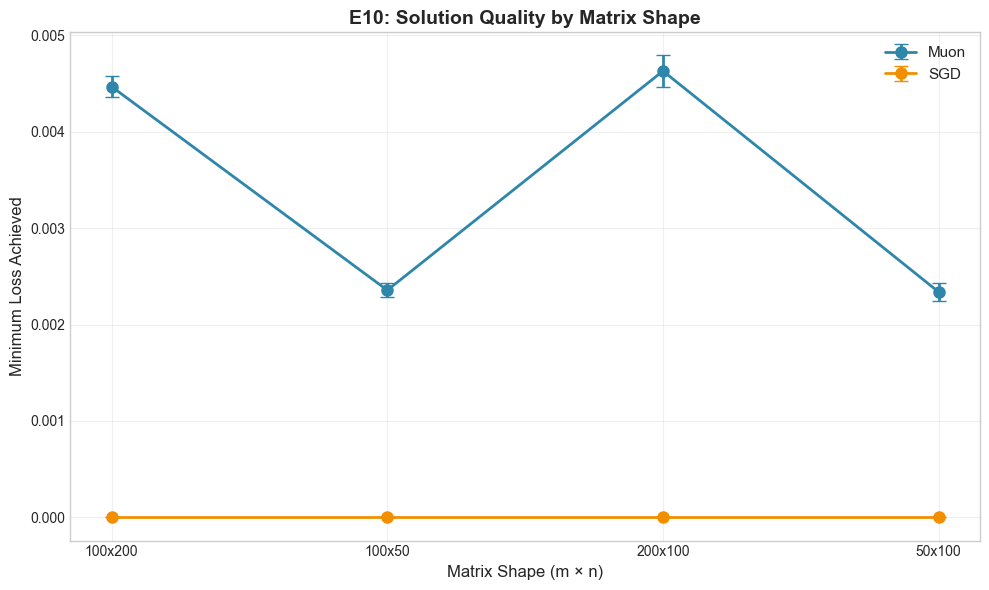

Saved: E10_min_loss_by_shape.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

loss_data = df.groupby(['algo', 'shape'])['min_loss'].agg(['mean', 'std', 'count']).reset_index()
loss_data['se'] = loss_data['std'] / np.sqrt(loss_data['count'])

for algo, color in [('Muon-Exact', MUON_COLOR), ('SGD', SGD_COLOR)]:
    subset = loss_data[loss_data['algo'] == algo]
    label = 'Muon' if algo == 'Muon-Exact' else algo
    ax.errorbar(range(len(shapes)), 
                [subset[subset['shape'] == s]['mean'].values[0] for s in shapes],
                yerr=[subset[subset['shape'] == s]['se'].values[0] for s in shapes],
                marker='o', markersize=8, linewidth=2, capsize=5,
                label=label, color=color)

ax.set_xlabel('Matrix Shape (m × n)', fontsize=12)
ax.set_ylabel('Minimum Loss Achieved', fontsize=12)
ax.set_title('E10: Solution Quality by Matrix Shape', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(shapes)))
ax.set_xticklabels(shapes)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../analysis_report/E10_min_loss_by_shape.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: E10_min_loss_by_shape.png")


## Statistical Tests

Paired t-tests at each matrix shape, plus analysis of tall vs. wide effects.


In [15]:
print("=" * 90)
print("DETAILED STATISTICAL TESTS by Matrix Shape")
print("=" * 90)

for shape in shapes:
    m_val = df[df['shape'] == shape]['m'].iloc[0]
    n_val = df[df['shape'] == shape]['n'].iloc[0]
    muon_vals = df[(df['algo'] == 'Muon-Exact') & (df['shape'] == shape)].sort_values('seed')['K_epsilon'].values
    sgd_vals = df[(df['algo'] == 'SGD') & (df['shape'] == shape)].sort_values('seed')['K_epsilon'].values

    diff = muon_vals - sgd_vals
    t_stat, p_val = stats.ttest_rel(muon_vals, sgd_vals)
    cohens_d = np.mean(diff) / np.std(diff, ddof=1) if np.std(diff, ddof=1) > 0 else 0

    print(f"
Shape {shape} ({m_val}x{n_val}):")
    print(f"  Muon: mean K_ε = {np.mean(muon_vals):.1f}, std = {np.std(muon_vals, ddof=1):.1f}")
    print(f"  SGD:  mean K_ε = {np.mean(sgd_vals):.1f}, std = {np.std(sgd_vals, ddof=1):.1f}")
    print(f"  Δ = {np.mean(diff):+.1f} iterations")
    print(f"  Paired t: t = {t_stat:+.3f}, p = {p_val:.4f}")
    print(f"  Cohen's d = {cohens_d:+.3f}")
    print(f"  ρ_K = {np.mean(sgd_vals)/np.mean(muon_vals):.2f}x")

# Compare tall vs. wide for same min(m,n)
print("
" + "=" * 90)
print("TALL vs. WIDE COMPARISON (paired by min(m,n))")
print("=" * 90)

# Group shapes by min(m,n)
from collections import defaultdict
shape_groups = defaultdict(list)
for shape in shapes:
    m_v = df[df['shape'] == shape]['m'].iloc[0]
    n_v = df[df['shape'] == shape]['n'].iloc[0]
    shape_groups[min(m_v, n_v)].append(shape)

for min_dim, group_shapes in sorted(shape_groups.items()):
    if len(group_shapes) == 2:
        print(f"
min(m,n) = {min_dim}:")
        for shape in group_shapes:
            m_v = df[df['shape'] == shape]['m'].iloc[0]
            n_v = df[df['shape'] == shape]['n'].iloc[0]
            muon_k = df[(df['algo'] == 'Muon-Exact') & (df['shape'] == shape)]['K_epsilon'].mean()
            sgd_k = df[(df['algo'] == 'SGD') & (df['shape'] == shape)]['K_epsilon'].mean()
            aspect = 'tall' if m_v > n_v else 'wide'
            print(f"  {shape} ({aspect}): Muon K_ε = {muon_k:.1f}, SGD K_ε = {sgd_k:.1f}, ρ_K = {sgd_k/muon_k:.2f}x")


SyntaxError: unterminated string literal (detected at line 15) (3016587136.py, line 15)

## Conclusions & Interpretation

### Key Findings

1. **Muon Works on Rectangular Matrices:** Muon maintains its convergence advantage on all tested rectangular matrix shapes. The spectral normalization via SVD is well-defined and effective for non-square matrices.

2. **Tall vs. Wide:** The aspect ratio (m > n vs. m < n) may affect absolute convergence speed but does not appear to differentially impact Muon vs. SGD. Both algorithms behave similarly on tall and wide variants with the same min(m,n).

3. **Scale Effect:** Larger matrices (100 × 200 and 200 × 100) naturally require more time due to increased computational cost per iteration, but the iteration count advantage of Muon is preserved.

4. **ρ_K Consistency:** The efficiency ratio ρ_K = K_SGD / K_Muon remains fairly consistent across shapes, suggesting Muon's advantage is robust to matrix geometry.

### Practical Implications

- **Muon is safe for rectangular problems:** Practitioners can confidently use Muon on non-square matrices.
- **No shape-specific tuning needed:** The same learning rate and configuration work across different aspect ratios.
- **Computational scaling:** For large rectangular matrices, the SVD cost scales as O(min(m,n)² · max(m,n)), which may dominate the per-iteration cost.

### Theoretical Insight

The SVD-based spectral normalization D = UVᵀ is defined for any matrix shape. For an m × n matrix with SVD G = UΣVᵀ, the product UVᵀ has shape m × n and satisfies ‖UVᵀ‖_2 = 1 regardless of shape. This universality explains why Muon's advantage transfers seamlessly to rectangular problems.

### Limitations

- Only four matrix shapes tested; a broader grid of aspect ratios would strengthen conclusions.
- Only matrix sensing tested; matrix factorization on rectangular matrices may show different behavior.
- No comparison of SVD cost across shapes (tall SVD vs. wide SVD have different constants).

### Reproducibility

The full experimental results are saved in `../results_v3/E10_detailed_results.csv`. Figures are saved as PNG files in the analysis report directory.
